In [1]:
from saris.utils import utils
import os
from typing import List, Tuple
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"  # to avoid memory fragmentation
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import tensorflow as tf
policy = tf.keras.mixed_precision.Policy("mixed_bfloat16")
tf.keras.mixed_precision.set_global_policy(policy)
tf.config.experimental.set_memory_growth(
    tf.config.experimental.list_physical_devices("GPU")[0], True
)
tf.random.set_seed(0)
from sionna.channel import (
    cir_to_ofdm_channel,
    subcarrier_frequencies,
    time_lag_discrete_time_channel,
    cir_to_time_channel,
    time_to_ofdm_channel,
)
from saris import sigmap
import math
import numpy as np

E0000 00:00:1739236353.940916  238314 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739236353.946143  238314 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, Camera

## One Flat Reflector

In [3]:
sionna_config_file = '/home/hieule/research/saris/configs/sionna_shared_ap.yaml'
sionna_config = utils.load_config(sionna_config_file)
compute_scene_path = "/home/hieule/research/saris/local_assets/blender/shared_ap_0/ceiling_idx/hallway.xml"
viz_scene_path = "/home/hieule/research/saris/local_assets/blender/shared_ap_0/idx/hallway.xml"

In [4]:
def compute_rot_angle(pt1: list, pt2: list) -> Tuple[float, float, float]:
    """Compute the rotation angles for vector pt1 to pt2."""
    x = pt2[0] - pt1[0]
    y = pt2[1] - pt1[1]
    z = pt2[2] - pt1[2]

    return cartesian2spherical(x, y, z)


def cartesian2spherical(x: float, y: float, z: float) -> Tuple[float, float, float]:
    # theta: zenith angle (0, pi), phi: azimuthal angle (0, 2pi)
    r = math.sqrt(x**2 + y**2 + z**2)
    theta = math.acos(z / r)
    phi = math.atan2(y, x)
    return r, theta, phi


def spherical2cartesian(r: float, theta: float, phi: float) -> Tuple[float, float, float]:
    # theta: zenith angle (0, pi), phi: azimuthal angle (0, 2pi)
    x = r * math.sin(theta) * math.cos(phi)
    y = r * math.sin(theta) * math.sin(phi)
    z = r * math.cos(theta)
    return x, y, z

rx_pos = np.array(sionna_config["rx_positions"], dtype=np.float32)
rt_pos = np.array(sionna_config["rt_positions"], dtype=np.float32)
tx_pos = np.array(sionna_config["tx_positions"], dtype=np.float32)

tx_orientations = []
for i in range(len(rt_pos)):
    r, theta, phi = compute_rot_angle(tx_pos[i], rt_pos[i])
    tx_orientations.append([phi, theta - math.pi / 2, 0.0])
sionna_config["tx_orientations"] = tx_orientations[::-1]
sionna_config["tx_positions"] = tx_pos[::-1]
print(f"tx_orientations: {tx_orientations}")

tx_orientations: [[-0.4379508469414478, 0.055362386909690864, 0.0], [-2.710406111740664, 0.060247634028242514, 0.0]]


In [5]:
np_rng = np.random.default_rng(0)

def is_eligible( pt, obstacle_pos, rx_pos):
    """
    Check if the position is eligible for new rx_pos.
    This function checks if the new rx_pos is not too close to obstacles and not too close to existing rx_pos.
    """
    # append new rx_pos that are not too close to obstacles
    is_obs_overlaped = False
    for pos in obstacle_pos:
        if np.linalg.norm(np.array(pos[:2]) - np.array(pt)) < 0.7:
            is_obs_overlaped = True
            # print(f"Obstacle at {pos[:2]} is too close to {pt}")
            break

    # make sure that distance between rx_pos is at least 1
    if not is_obs_overlaped:
        if not any(np.linalg.norm(np.array(pos[:2]) - np.array(pt)) < 1.5 for pos in rx_pos):
            # print("Eligible position found at", pt)
            return True
    # print(f"Position {pt} is not eligible")
    return False

def _prepare_rx_positions():
    rx_pos = []
    while len(rx_pos) < len(sionna_config["rx_positions"]):
        x = np_rng.uniform(low=rx_pos_range[0][0], high=rx_pos_range[0][1])
        y = np_rng.uniform(low=rx_pos_range[1][0], high=rx_pos_range[1][1])
        pt = [x, y]
        if is_eligible(pt, obstacle_pos, rx_pos):
            rx_pos.append([x, y, 1.5])

    return rx_pos

rx_pos_range = [[-4.39634, 4.40138], [-19.6031, -10.7053]]  # x  # y
obstacle_pos = [[2.37, -17.656], [-2.6, -11.945], [1.86, -10.7654], [-1.71, -15.6846]]
rx_pos = _prepare_rx_positions()
sionna_config["rx_positions"] = rx_pos

In [6]:
sig_cmap = sigmap.engine.SignalCoverageMap(
    sionna_config, compute_scene_path, viz_scene_path
)
coverage_map = sig_cmap.compute_cmap()


I0000 00:00:1739236357.356626  238314 gpu_process_state.cc:201] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1739236357.356887  238314 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4603 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


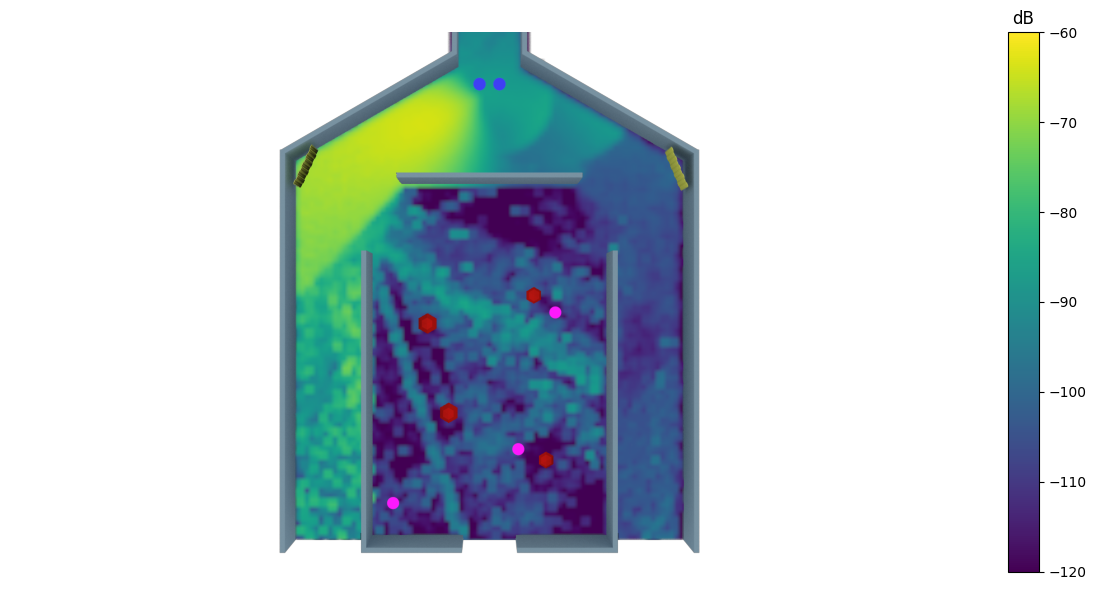

In [7]:
scene = sig_cmap.render(coverage_map)

In [15]:
scene.transmitters['tx_0'].orientation

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([-0.41749397,  0.0529371 ,  0.        ], dtype=float32)>

In [14]:
scene.transmitters['tx_1'].orientation

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([-2.7309904 ,  0.05754554,  0.        ], dtype=float32)>

In [6]:
sig_cmap.render_to_file(coverage_map, filename="room_flat_reflecor.png")

In [9]:
scene.preview(coverage_map=coverage_map, show_orientations=True, resolution=(1280, 720))

Renderer(camera=PerspectiveCamera(aspect=1.7777777777777777, children=(DirectionalLight(intensity=0.25, matrix…

In [5]:
bandwidth = 100e6
(l_min, l_max) = time_lag_discrete_time_channel(
            bandwidth, 10e-9
        )

paths = sig_cmap.compute_paths()
cir = paths.cir()
# a: [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps], tf.complex
a, tau = cir
# [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, l_max - l_min + 1], tf.complex
channels: tf.Tensor = cir_to_time_channel(bandwidth, a, tau, l_min, l_max)
large_scale = tf.reduce_mean(
    tf.reduce_sum(tf.square(tf.abs(channels)), axis=6, keepdims=True),
    axis=(2, 4, 5),
    keepdims=True,
)
path_gains = tf.squeeze(large_scale, axis=(0, 2, 3, 4, 5, 6)).numpy()

In [5]:
path_gains = sig_cmap.get_path_gain(coverage_map)
path_gains = np.asarray(path_gains)
path_gain_dBs = utils.linear2dB(path_gains)
print(f"path_gains: {path_gains}")
print(f"path_gain_dBs: {np.round(path_gain_dBs, 4)} dB")

avg_path_gain_dB = np.mean(path_gain_dBs)
print(f"avg_path_gain_dB: {avg_path_gain_dB:.4f} dB")

path_gains: [7.24559857e-11 1.65574134e-11 2.34918283e-11]
path_gain_dBs: [-101.3993 -107.8101 -106.2908] dB
avg_path_gain_dB: -105.1667 dB


## No Reflector

In [12]:
sionna_config_file = '/home/hieule/research/saris/configs/sionna_room_multi_users.yaml'
sionna_config = utils.load_config(sionna_config_file)
compute_scene_path = "/home/hieule/research/saris/default_scenes/blender/room_no_ref/ceiling_idx/hallway.xml"
viz_scene_path = "/home/hieule/research/saris/default_scenes/blender/room_no_ref/idx/hallway.xml"

ris_pos: [2.09223, -5.36251, 2.06059]
tx_pos: [1.0, 0.0, 2.5]


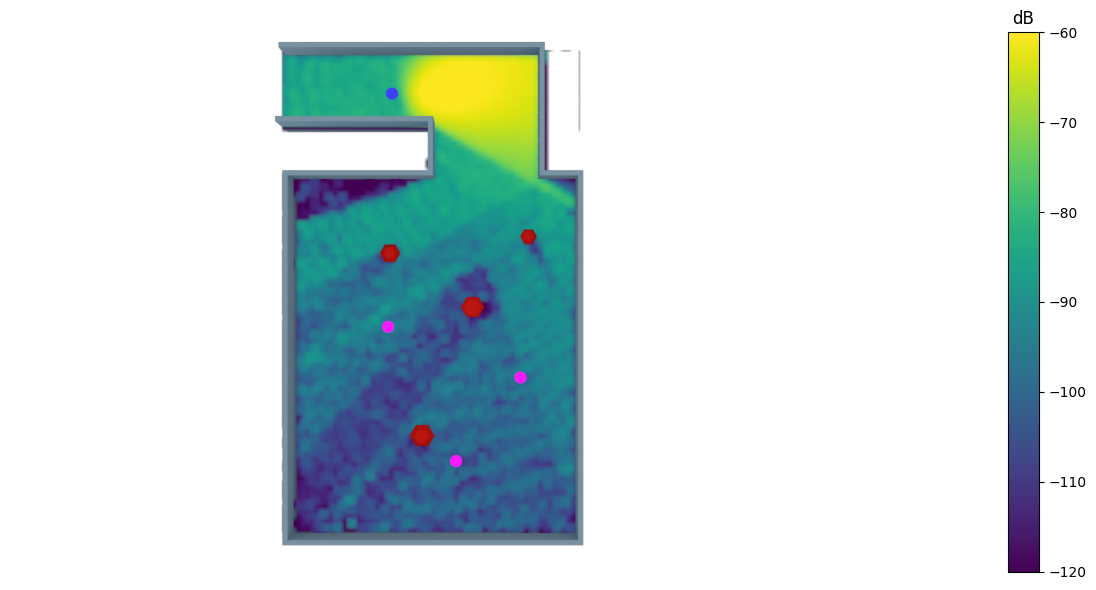

In [13]:
def compute_rot_angle(pt1: list, pt2: list) -> Tuple[float, float, float]:
    """Compute the rotation angles for vector pt1 to pt2."""
    x = pt2[0] - pt1[0]
    y = pt2[1] - pt1[1]
    z = pt2[2] - pt1[2]

    return cartesian2spherical(x, y, z)


def cartesian2spherical(x: float, y: float, z: float) -> Tuple[float, float, float]:
    # theta: zenith angle (0, pi), phi: azimuthal angle (0, 2pi)
    r = math.sqrt(x**2 + y**2 + z**2)
    theta = math.acos(z / r)
    phi = math.atan2(y, x)
    return r, theta, phi


def spherical2cartesian(r: float, theta: float, phi: float) -> Tuple[float, float, float]:
    # theta: zenith angle (0, pi), phi: azimuthal angle (0, 2pi)
    x = r * math.sin(theta) * math.cos(phi)
    y = r * math.sin(theta) * math.sin(phi)
    z = r * math.cos(theta)
    return x, y, z



ris_pos = sionna_config['ris_positions'][0]
tx_pos = sionna_config['tx_positions'][0]

print(f"ris_pos: {ris_pos}")
print(f"tx_pos: {tx_pos}")

r, theta, phi = compute_rot_angle(tx_pos, ris_pos)


sionna_config['tx_orientations'] = [[phi, theta - math.pi/2, 0.0]]
sig_cmap = sigmap.engine.SignalCoverageMap(
    sionna_config, compute_scene_path, viz_scene_path
)
coverage_map = sig_cmap.compute_cmap()
scene = sig_cmap.render(coverage_map)


In [15]:
sig_cmap.render_to_file(coverage_map, filename="room_no_reflecor.png")

In [9]:
bandwidth = 100e6
(l_min, l_max) = time_lag_discrete_time_channel(
            bandwidth, 10e-9
        )

paths = sig_cmap.compute_paths()
cir = paths.cir()
# a: [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps], tf.complex
a, tau = cir
# [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, l_max - l_min + 1], tf.complex
channels: tf.Tensor = cir_to_time_channel(bandwidth, a, tau, l_min, l_max)
large_scale = tf.reduce_mean(
    tf.reduce_sum(tf.square(tf.abs(channels)), axis=6, keepdims=True),
    axis=(2, 4, 5),
    keepdims=True,
)
path_gains = tf.squeeze(large_scale, axis=(0, 2, 3, 4, 5, 6)).numpy()

In [10]:
path_gain_dBs = utils.linear2dB(path_gains)
path_gain_dBs

array([-112.28717 , -112.428635, -109.58728 ], dtype=float32)

In [14]:
path_gains = sig_cmap.get_path_gain(coverage_map)
path_gains = np.asarray(path_gains)
path_gain_dBs = utils.linear2dB(path_gains)
print(f"path_gains: {path_gains}")
print(f"path_gain_dBs: {np.round(path_gain_dBs, 4)} dB")

avg_path_gain_dB = np.mean(path_gain_dBs)
print(f"avg_path_gain_dB: {avg_path_gain_dB:.4f} dB")

path_gains: [4.50094961e-11 3.91118388e-12 8.28152685e-11]
path_gain_dBs: [-103.467  -114.0769 -100.8189] dB
avg_path_gain_dB: -106.1209 dB


## Reflector

In [3]:
sionna_config_file = '/home/hieule/research/saris/configs/sionna_L_multi_users.yaml'
sionna_config = utils.load_config(sionna_config_file)
compute_scene_path = "/home/hieule/research/saris/local_assets/blender/hallway_L_0/ceiling_idx/hallway.xml"
viz_scene_path = "/home/hieule/research/saris/local_assets/blender/hallway_L_0/idx/hallway.xml"

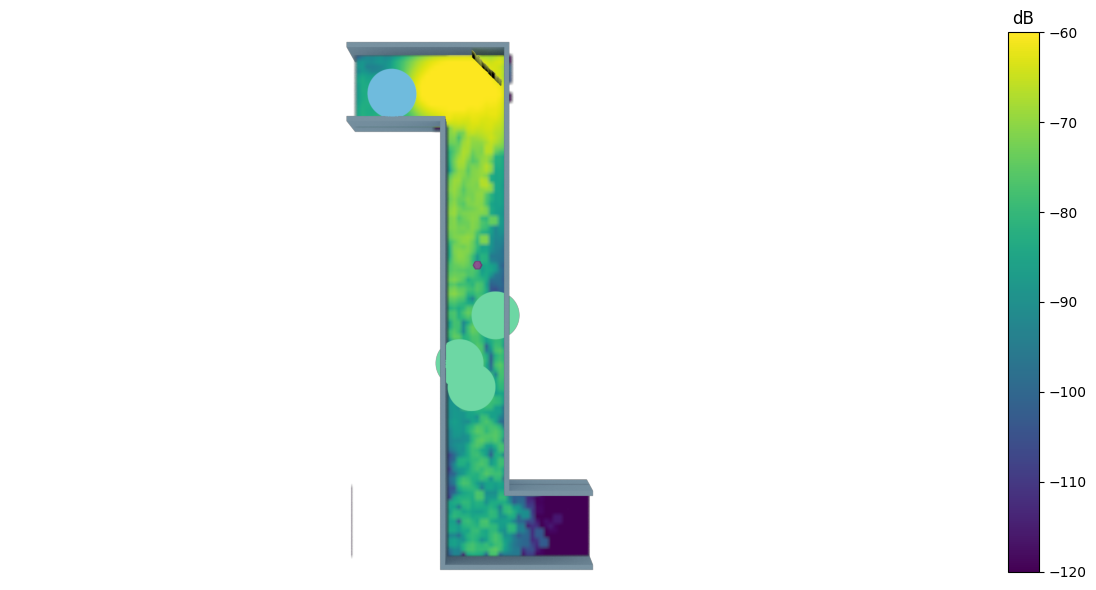

In [4]:
def compute_rot_angle(pt1: list, pt2: list) -> Tuple[float, float, float]:
    """Compute the rotation angles for vector pt1 to pt2."""
    x = pt2[0] - pt1[0]
    y = pt2[1] - pt1[1]
    z = pt2[2] - pt1[2]

    return cartesian2spherical(x, y, z)


def cartesian2spherical(x: float, y: float, z: float) -> Tuple[float, float, float]:
    # theta: zenith angle (0, pi), phi: azimuthal angle (0, 2pi)
    r = math.sqrt(x**2 + y**2 + z**2)
    theta = math.acos(z / r)
    phi = math.atan2(y, x)
    return r, theta, phi


def spherical2cartesian(r: float, theta: float, phi: float) -> Tuple[float, float, float]:
    # theta: zenith angle (0, pi), phi: azimuthal angle (0, 2pi)
    x = r * math.sin(theta) * math.cos(phi)
    y = r * math.sin(theta) * math.sin(phi)
    z = r * math.cos(theta)
    return x, y, z

ris_pos = sionna_config['ris_positions'][0]
tx_pos = sionna_config['tx_positions'][0]

r, theta, phi = compute_rot_angle(tx_pos, ris_pos)

sionna_config['tx_orientations'] = [[phi, theta - math.pi/2, 0.0]]
sig_cmap = sigmap.engine.SignalCoverageMap(
    sionna_config, compute_scene_path, viz_scene_path
)
coverage_map = sig_cmap.compute_cmap()
scene = sig_cmap.render(coverage_map)

In [5]:
scene.preview(show_orientations=True, resolution=(1280, 720))

Renderer(camera=PerspectiveCamera(aspect=1.7777777777777777, children=(DirectionalLight(intensity=0.25, positi…

In [9]:
coverage_map.path_gain.shape

TensorShape([1, 51, 107])

In [16]:
tmp = []
for pos in coverage_map.rx_pos:
    path_gain = coverage_map.path_gain[:, pos[1], pos[0]]
    tmp.append(path_gain)

In [17]:
tmp = np.asarray(tmp)
print(f"tmp shape: {tmp.shape}")
print(f"tmp: \t{utils.linear2dB(tmp)}")

tmp shape: (3, 1)
tmp: 	[[ -83.32294]
 [-105.13664]
 [-103.75015]]


In [18]:
path_gains = sig_cmap.get_path_gain(coverage_map)
path_gains
print(f"cpath_gain_dB: \t{utils.linear2dB(path_gains)}")

cpath_gain_dB: 	[ -83.32293042 -105.13664068 -103.75015014]


In [ ]:
a = coverage_map.cell_to_tx("rss")

<tf.Tensor: shape=(51, 107), dtype=int64, numpy=
array([[-1,  0,  0, ..., -1, -1, -1],
       [-1,  0,  0, ..., -1, -1, -1],
       [-1,  0,  0, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ...,  0,  0, -1],
       [-1, -1, -1, ...,  0,  0, -1],
       [-1, -1, -1, ..., -1, -1, -1]])>

In [ ]:
bandwidth = 100e6
(l_min, l_max) = time_lag_discrete_time_channel(
            bandwidth, 10e-9
        )

paths = sig_cmap.compute_paths()
cir = paths.cir()
# a: [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps], tf.complex
a, tau = cir
# [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, l_max - l_min + 1], tf.complex
channels: tf.Tensor = cir_to_time_channel(bandwidth, a, tau, l_min, l_max)
large_scale = tf.reduce_mean(
    tf.reduce_sum(tf.square(tf.abs(channels)), axis=6, keepdims=True),
    axis=(2, 4, 5),
    keepdims=True,
)
path_gains = tf.squeeze(large_scale, axis=(0, 2, 3, 4, 5, 6)).numpy()

In [ ]:
path_gain_dBs = utils.linear2dB(path_gains)
path_gain_dBs

array([-80.63668, -93.44491, -87.61919], dtype=float32)